# 01 · Huấn luyện cấu hình gốc

Một lượt chạy end-to-end với cấu hình nền: `transpose` + `full skip` +
`BCE+Dice`. Mọi thí nghiệm sau đều so với cấu hình này.

Người phụ trách: **SV A**.

In [1]:
# Chạy được cả trên Colab lẫn máy cá nhân
import sys, os
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB and not Path("unet-kvasir").exists():
    # !git clone <repo cua nhom> unet-kvasir
    pass
ROOT = Path("unet-kvasir") if Path("unet-kvasir").exists() else Path("..")
os.chdir(ROOT.resolve())
sys.path.insert(0, str(Path.cwd()))

%load_ext autoreload
%autoreload 2

from src import *
print("Thư mục làm việc:", Path.cwd())
print("Thiết bị:", get_device())

Thư mục làm việc: /root/workspace/unet-kvasir
Thiết bị: cuda


In [2]:
cfg = Config(
    loss_name="bce_dice",
    up_mode="transpose",
    skip_mode="full",
    epochs=40,
    batch_size=8,
    seed=42,
)
print("run_id:", cfg.run_id)

run_id: bce_dice-transpose-full-s42-3790b4


Nếu Colab báo hết VRAM, hạ `base_channels=32` hoặc `batch_size=4`.
Nhớ ghi lại thay đổi đó trong báo cáo vì nó ảnh hưởng tới mọi so sánh.

In [3]:
result = run_experiment(cfg, skip_if_logged=False)

=== bce_dice-transpose-full-s42-3790b4 === 31,037,633 tham số, thiết bị cuda
epoch   1/40 | train 0.6585 | val 0.5408 | val dice 0.2929 | val iou 0.1946 *
epoch   2/40 | train 0.5602 | val 0.5450 | val dice 0.2390 | val iou 0.1543
epoch   3/40 | train 0.5239 | val 0.7456 | val dice 0.0190 | val iou 0.0100
epoch   4/40 | train 0.5078 | val 0.4750 | val dice 0.4894 | val iou 0.3485 *
epoch   5/40 | train 0.4957 | val 0.4662 | val dice 0.4877 | val iou 0.3491
epoch   6/40 | train 0.4884 | val 0.6029 | val dice 0.4593 | val iou 0.3292
epoch   7/40 | train 0.4868 | val 0.4619 | val dice 0.5269 | val iou 0.3900 *
epoch   8/40 | train 0.4761 | val 0.4846 | val dice 0.3984 | val iou 0.2872
epoch   9/40 | train 0.4633 | val 0.4607 | val dice 0.4752 | val iou 0.3513
epoch  10/40 | train 0.4594 | val 0.4340 | val dice 0.5532 | val iou 0.4117 *
epoch  11/40 | train 0.4562 | val 0.4256 | val dice 0.5509 | val iou 0.4165
epoch  12/40 | train 0.4528 | val 0.4280 | val dice 0.5170 | val iou 0.3903
epo

## Đường cong huấn luyện

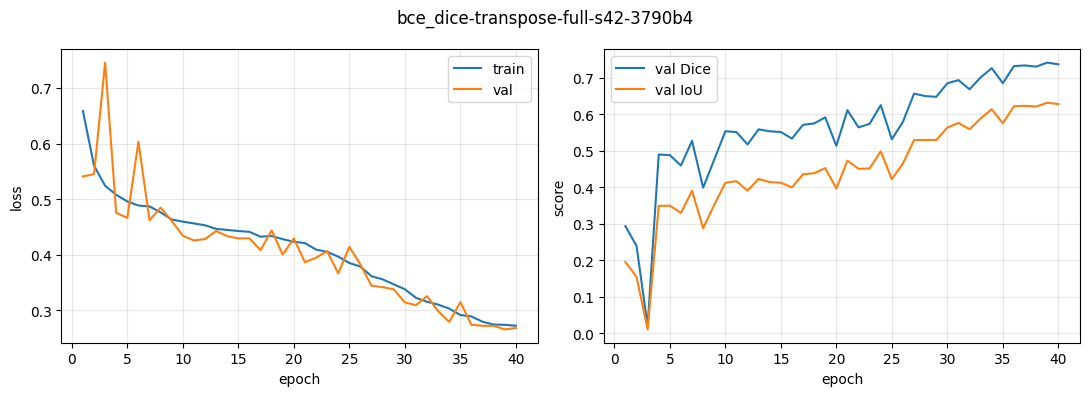

In [4]:
from src.viz import plot_history

fig = plot_history(result["history"], title=cfg.run_id,
                   save_path=f"{cfg.fig_dir}/history_{cfg.run_id}.png")

## Đọc gì từ hình này

- `train_loss` giảm nhưng `val_loss` tăng dần từ một epoch nào đó → quá khớp.
- `val_dice` dao động mạnh giữa các epoch → learning rate còn cao.
- `val_dice` phẳng ngay từ đầu → nghi ngờ lỗi dữ liệu, kiểm lại notebook 00.

## Xem thử dự đoán

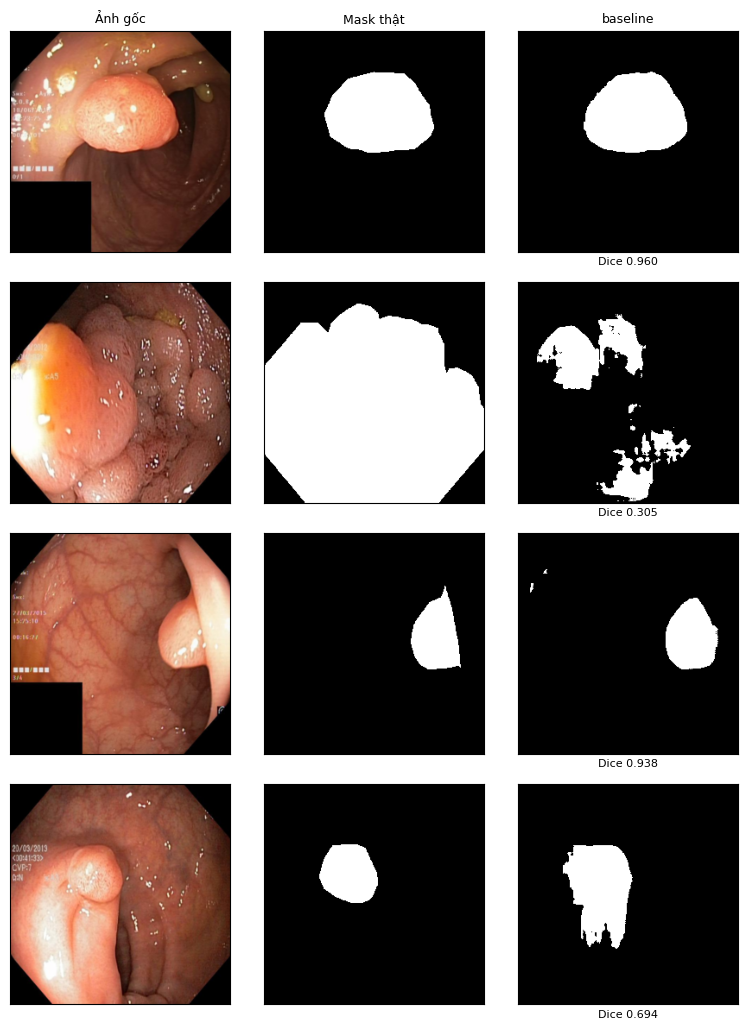

In [5]:
from src.viz import comparison_grid

splits = load_splits(cfg.split_dir)
test_ds = KvasirSegDataset(cfg.data_root, splits["test"],
                           SegTransform(cfg.image_size, train=False))
fig = comparison_grid(test_ds, {"baseline": result["model"]},
                      indices=range(4), device=get_device())